# Advanced Machine Learning 2026/2027
## Projeto: Modeling Recovery after Lower-Limb Musculoskeletal Injury
### M1 — Mixture Models

**Grupo:** 14

| Número | Nome |
|---|---|
| fc68043 | David Belykh |
| fc68080 | Matilde Quitério |
| fc68091 | Ramyad Raadi |

### Declaração sobre o uso de IA generativa
Foi utilizada a ferramenta de IA generativa **ChatGPT (OpenAI)** como apoio à estruturação do notebook, geração e depuração de código, clarificação de conceitos de Gaussian Mixture Models e melhoria da redação. O conteúdo, os resultados e as interpretações devem ser revistos e validados pelos elementos do grupo antes da submissão.

## 0. Configuração e carregamento dos dados

Neste milestone, cada linha de `rehabilitation.csv` (um par doente-semana) é tratada como uma **observação independente**, conforme indicado no enunciado.

O objetivo é descobrir estrutura latente apenas a partir de indicadores observáveis do estado de reabilitação. Por isso, **`state`, `intervention` e `utility` não são utilizadas para ajustar o GMM**. Estas variáveis serão usadas apenas posteriormente para interpretar os clusters encontrados.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

STATE_ORDER = ["Limited", "Recovering", "Functional"]
INTERV_ORDER = ["Rest/Recovery", "Light Exercise", "Standard Therapy", "Intensive Therapy"]
MEASURES = [
    "mobility",
    "pain",
    "fatigue",
    "functional_confidence",
    "activity",
    "adherence",
]

def find_file(filename, search_paths=(".", "..", "/mnt/data")):
    for base in search_paths:
        if not os.path.exists(base):
            continue
        for root, _, files in os.walk(base):
            if filename in files:
                return os.path.join(root, filename)
    raise FileNotFoundError(
        f"Não foi possível encontrar {filename}. Coloque o notebook na raiz do projeto "
        "ou garanta que rehabilitation.csv está dentro da pasta dataset/."
    )

rehab_path = find_file("rehabilitation.csv")
rehab = pd.read_csv(rehab_path)

print("Ficheiro:", rehab_path)
print("Dimensão:", rehab.shape)
display(rehab.head())

Ficheiro: .\dataset\dataset\rehabilitation.csv
Dimensão: (42000, 11)


,patient_id,week,state,mobility,pain,fatigue,functional_confidence,activity,adherence,intervention,utility
0,1,0,Limited,54.8,7.1,4.8,66.7,30.1,78.9,Light Exercise,-0.2
1,2,0,Limited,45.5,7.8,6.9,51.4,26.6,73.8,Light Exercise,-8.1
2,3,0,Recovering,47.3,5.9,5.5,60.5,67.6,51.2,Intensive Therapy,-6.0
3,4,0,Limited,27.3,6.3,6.5,19.5,12.7,58.5,Light Exercise,-4.1
4,5,0,Recovering,51.5,5.3,5.8,51.1,38.9,55.7,Light Exercise,0.4


## Task 1 — Feature selection and preprocessing

### Seleção de variáveis

Foram selecionadas as seis medições observáveis do processo de reabilitação:

- `mobility`
- `pain`
- `fatigue`
- `functional_confidence`
- `activity`
- `adherence`

Estas variáveis descrevem diretamente a condição funcional e os sintomas do doente em cada semana. Não incluímos `state`, porque é a variável latente de referência que queremos comparar com os clusters; `intervention`, porque representa uma decisão terapêutica; nem `utility`, porque representa um resultado/recompensa.

Como as variáveis estão em escalas diferentes (por exemplo, dor/fadiga em 0–10 e mobilidade/confiança em 0–100), é necessário **estandardizá-las** antes de ajustar o GMM. Foi utilizado `StandardScaler`, que transforma cada variável para média aproximadamente 0 e desvio-padrão aproximadamente 1.

In [3]:
# Verificações básicas antes do modelo
missing = rehab[MEASURES].isna().sum()
print("Valores em falta nas features:")
display(missing.to_frame("n_missing"))

X_raw = rehab[MEASURES].copy()

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X, columns=MEASURES, index=rehab.index)

print()
print("Média e desvio-padrão após estandardização:")
display(pd.DataFrame({
    "mean": X_scaled.mean(),
    "std": X_scaled.std(ddof=0)
}).round(3))

Valores em falta nas features:


,n_missing
mobility,0
pain,0
fatigue,0
functional_confidence,0
activity,0
adherence,0



Média e desvio-padrão após estandardização:


,mean,std
mobility,-0.0,1.0
pain,0.0,1.0
fatigue,0.0,1.0
functional_confidence,0.0,1.0
activity,0.0,1.0
adherence,-0.0,1.0


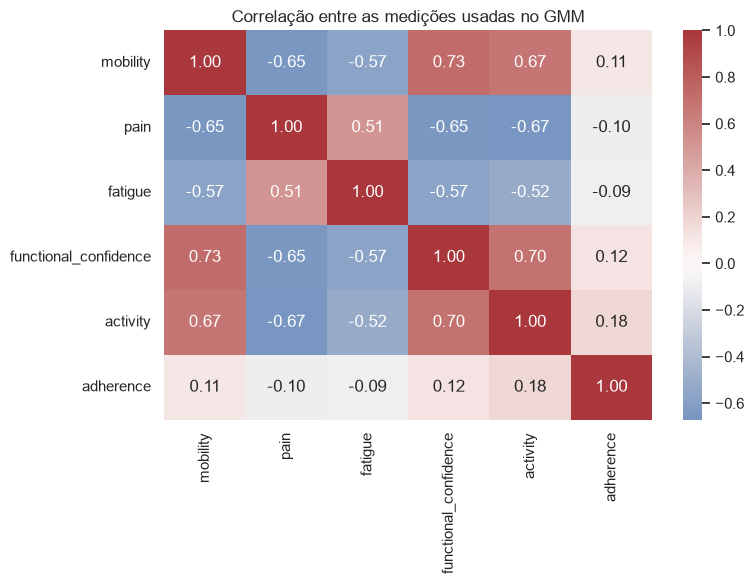

In [4]:
# Correlações entre as features selecionadas
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlação entre as medições usadas no GMM")
plt.tight_layout()
plt.show()

**Nota de interpretação:** as medições não são independentes entre si — várias descrevem dimensões relacionadas do estado funcional. Um GMM com covariância `full` é adequado neste contexto porque permite que cada componente represente correlações diferentes entre as variáveis.

## Task 2 — Model fitting and selection

Foram ajustados Gaussian Mixture Models com **2 a 8 componentes**, usando a estrutura de covariância `full`. Para reduzir a sensibilidade à inicialização do algoritmo EM, são usadas várias inicializações (`n_init=5`).

A seleção do número de componentes é feita principalmente através do **BIC (Bayesian Information Criterion)**, usando o AIC como informação complementar. Em ambos os critérios, **valores menores são preferíveis**, pois representam um melhor compromisso entre qualidade do ajuste e complexidade do modelo.

In [ ]:
ks = range(2, 9)
models = {}
rows = []

for k in ks:
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        n_init=5,
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
    )
    model.fit(X)
    models[k] = model
    rows.append({
        "K": k,
        "AIC": model.aic(X),
        "BIC": model.bic(X),
        "log_likelihood_per_obs": model.score(X),
        "converged": model.converged_,
        "n_iter": model.n_iter_,
    })

criteria = pd.DataFrame(rows)
display(criteria.round(2))

best_k_bic = int(criteria.loc[criteria["BIC"].idxmin(), "K"])
best_k_aic = int(criteria.loc[criteria["AIC"].idxmin(), "K"])

print(f"K selecionado pelo BIC: {best_k_bic}")
print(f"K selecionado pelo AIC: {best_k_aic}")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(criteria["K"], criteria["BIC"], marker="o", label="BIC")
plt.plot(criteria["K"], criteria["AIC"], marker="o", label="AIC")
plt.axvline(best_k_bic, linestyle="--", alpha=0.7, label=f"BIC mínimo: K={best_k_bic}")
plt.xlabel("Número de componentes (K)")
plt.ylabel("Critério de informação")
plt.title("Seleção do número de componentes")
plt.legend()
plt.tight_layout()
plt.show()

### Modelo selecionado

Para a análise seguinte é utilizado o modelo com o **menor BIC**. Esta opção favorece um modelo que explique bem os dados sem adicionar componentes desnecessários.

> **Depois de executar:** confirmar se AIC e BIC sugerem o mesmo número de componentes. Se sugerirem valores diferentes, discutir brevemente que o AIC tende a penalizar menos a complexidade e pode favorecer um modelo com mais componentes.

In [ ]:
gmm = models[best_k_bic]

# Cluster mais provável para cada observação
cluster = gmm.predict(X)
posterior = gmm.predict_proba(X)

m1 = rehab.copy()
m1["cluster"] = cluster
m1["max_posterior"] = posterior.max(axis=1)
m1["second_posterior"] = np.sort(posterior, axis=1)[:, -2]
m1["posterior_margin"] = m1["max_posterior"] - m1["second_posterior"]

# Entropia normalizada: 0 = muito certo; 1 = máxima ambiguidade
p_safe = np.clip(posterior, 1e-15, 1)
entropy = -(p_safe * np.log(p_safe)).sum(axis=1)
m1["posterior_entropy"] = entropy / np.log(best_k_bic)

cluster_counts = m1["cluster"].value_counts().sort_index()
cluster_sizes = pd.DataFrame({
    "n": cluster_counts,
    "%": 100 * cluster_counts / len(m1)
})
display(cluster_sizes.round(2))

### Posterior membership probabilities

Ao contrário de um método de clustering rígido, o GMM atribui a cada observação uma **probabilidade posterior de pertencer a cada componente**. Assim, é possível identificar patient-weeks claramente atribuídos a um cluster e observações que se encontram em zonas de sobreposição entre componentes.

In [ ]:
posterior_summary = m1[["max_posterior", "posterior_margin", "posterior_entropy"]].describe().T
posterior_summary["median"] = m1[["max_posterior", "posterior_margin", "posterior_entropy"]].median()
display(posterior_summary.round(3))

for threshold in [0.60, 0.70, 0.80, 0.90]:
    pct = 100 * (m1["max_posterior"] < threshold).mean()
    print(f"Observações com max posterior < {threshold:.2f}: {pct:.2f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(m1["max_posterior"].to_numpy(), bins=30)
axes[0].set_title("Confiança da atribuição ao cluster")
axes[0].set_xlabel("Maior probabilidade posterior")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=m1, x="cluster", y="max_posterior", ax=axes[1])
axes[1].set_title("Confiança por cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Maior probabilidade posterior")

plt.tight_layout()
plt.show()

In [ ]:
# Exemplos das observações mais ambíguas
posterior_cols = [f"P(cluster={j})" for j in range(best_k_bic)]
posterior_df = pd.DataFrame(posterior, columns=posterior_cols, index=m1.index)

ambiguous_idx = m1.nsmallest(10, "max_posterior").index
ambiguous_examples = pd.concat([
    m1.loc[ambiguous_idx, ["patient_id", "week", "state", "cluster", "max_posterior"] + MEASURES],
    posterior_df.loc[ambiguous_idx]
], axis=1)

display(ambiguous_examples.round(3))

**Interpretação a completar após execução:**

- Se a maioria dos valores de `max_posterior` estiver próxima de 1, as atribuições são geralmente claras.
- Se existir uma fração relevante de observações com probabilidades semelhantes para dois componentes, existe sobreposição entre os perfis latentes.
- As observações ambíguas são particularmente interessantes porque podem representar patient-weeks em zonas intermédias de recuperação ou casos cujas medições não formam um perfil totalmente consistente.

## Task 3 — Cluster characterization

Nesta secção, os clusters são caracterizados através das mesmas medições utilizadas no modelo. Como os identificadores (`0`, `1`, ...) são arbitrários, a interpretação deve basear-se nos perfis das variáveis e **não no número do cluster**.

In [ ]:
cluster_means = m1.groupby("cluster")[MEASURES].mean()
cluster_stds = m1.groupby("cluster")[MEASURES].std()

print("Médias das medições na escala original:")
display(cluster_means.round(2))

print("Desvios-padrão das medições na escala original:")
display(cluster_stds.round(2))

In [ ]:
# Médias dos clusters na escala estandardizada (mais fácil de comparar entre variáveis)
scaled_with_cluster = X_scaled.copy()
scaled_with_cluster["cluster"] = m1["cluster"].values
cluster_z = scaled_with_cluster.groupby("cluster")[MEASURES].mean()

plt.figure(figsize=(9, max(3.5, 0.65 * best_k_bic + 1.5)))
sns.heatmap(cluster_z, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Perfil médio estandardizado de cada cluster")
plt.xlabel("Medição")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:
# Distribuições das features por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, MEASURES):
    sns.boxplot(data=m1, x="cluster", y=feature, ax=ax, showfliers=False)
    ax.set_title(feature)
plt.suptitle("Distribuição das medições por cluster", y=1.02)
plt.tight_layout()
plt.show()

### Comparação com os recovery states verdadeiros

`state` não foi usado no ajuste do modelo. Nesta fase, utilizamo-lo apenas como **ground truth externo** para perceber se os grupos latentes descobertos pelo GMM correspondem aos estados `Limited`, `Recovering` e `Functional` ou se captam uma estrutura diferente.

In [ ]:
cluster_vs_state_n = pd.crosstab(m1["cluster"], m1["state"]).reindex(columns=STATE_ORDER, fill_value=0)
cluster_vs_state_pct = pd.crosstab(
    m1["cluster"], m1["state"], normalize="index"
).reindex(columns=STATE_ORDER, fill_value=0) * 100

print("Contagens:")
display(cluster_vs_state_n)

print("Composição percentual de cada cluster:")
display(cluster_vs_state_pct.round(1))

In [ ]:
plt.figure(figsize=(8, max(3.8, 0.6 * best_k_bic + 1.5)))
sns.heatmap(cluster_vs_state_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Recovery states dentro de cada cluster (%)")
plt.xlabel("Recovery state verdadeiro")
plt.ylabel("Cluster GMM")
plt.tight_layout()
plt.show()

In [ ]:
# Métricas externas de concordância (não assumem correspondência entre os números dos clusters e os labels)
ari = adjusted_rand_score(m1["state"], m1["cluster"])
nmi = normalized_mutual_info_score(m1["state"], m1["cluster"])
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

In [ ]:
# Para cada cluster: state dominante e pureza
cluster_state_summary = cluster_vs_state_pct.copy()
cluster_state_summary["dominant_state"] = cluster_state_summary[STATE_ORDER].idxmax(axis=1)
cluster_state_summary["purity_%"] = cluster_state_summary[STATE_ORDER].max(axis=1)
display(cluster_state_summary.round(1))

# Quais pares de states aparecem mais misturados no mesmo cluster?
for c in cluster_vs_state_pct.index:
    ordered = cluster_vs_state_pct.loc[c, STATE_ORDER].sort_values(ascending=False)
    print(
        f"Cluster {c}: mais frequentes = {ordered.index[0]} ({ordered.iloc[0]:.1f}%) e "
        f"{ordered.index[1]} ({ordered.iloc[1]:.1f}%)"
    )

**Pontos a discutir após execução:**

1. Identificar quais medições distinguem melhor os clusters (por exemplo, maior mobilidade/confiança/atividade versus maior dor/fadiga).
2. Verificar se existe uma ordenação natural dos clusters ao longo de um eixo de recuperação funcional.
3. Avaliar se existe correspondência forte com `Limited`, `Recovering` e `Functional` ou se há sobreposição considerável.
4. Identificar os pares de states que mais se misturam no mesmo cluster. Uma razão plausível para a sobreposição é que o `state` é uma categoria discreta, enquanto a condição observável do doente varia de forma contínua; patient-weeks próximos de uma transição podem apresentar perfis muito semelhantes apesar de terem labels diferentes.

## Task 4 — Interpretation

Agora interpretamos os clusters do ponto de vista da reabilitação e estudamos `intervention` e `utility`. Estas variáveis continuam a **não fazer parte do ajuste do GMM**; são utilizadas apenas para caracterização posterior.

In [ ]:
# Resumo automático para apoiar a interpretação de cada cluster
for c in cluster_means.index:
    z = cluster_z.loc[c].sort_values()
    low = ", ".join([f"{name} ({value:+.2f} SD)" for name, value in z.head(2).items()])
    high = ", ".join([f"{name} ({value:+.2f} SD)" for name, value in z.tail(2).sort_values(ascending=False).items()])
    dominant = cluster_state_summary.loc[c, "dominant_state"]
    purity = cluster_state_summary.loc[c, "purity_%"]
    print(f"Cluster {c}: valores relativamente baixos em {low}; altos em {high}.")
    print(f"           State mais frequente: {dominant} ({purity:.1f}%).")
    print()

### Intervention por cluster

In [ ]:
cluster_vs_intervention = pd.crosstab(
    m1["cluster"], m1["intervention"], normalize="index"
)
# Reordenar apenas categorias que existam no dataset
cols = [c for c in INTERV_ORDER if c in cluster_vs_intervention.columns]
extra = [c for c in cluster_vs_intervention.columns if c not in cols]
cluster_vs_intervention = cluster_vs_intervention[cols + extra] * 100

display(cluster_vs_intervention.round(1))

plt.figure(figsize=(9, max(3.8, 0.6 * best_k_bic + 1.5)))
sns.heatmap(cluster_vs_intervention, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Distribuição das intervenções dentro de cada cluster (%)")
plt.xlabel("Intervention")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### Utility por cluster

In [ ]:
utility_summary = m1.groupby("cluster")["utility"].agg(["count", "mean", "std", "median", "min", "max"])
display(utility_summary.round(2))

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=m1, x="cluster", y="utility", showfliers=False)
plt.title("Utility por cluster")
plt.xlabel("Cluster")
plt.ylabel("Utility")
plt.tight_layout()
plt.show()

### Recovery levels ou padrões adicionais?

A comparação entre os perfis médios, a composição por `state`, as probabilidades posteriores, `intervention` e `utility` permite avaliar se os componentes correspondem essencialmente a diferentes **níveis de recuperação** ou se subdividem pacientes com recuperação semelhante segundo outros padrões.

Alguns sinais de que o GMM representa principalmente recovery level seriam:

- clusters ordenados de baixa para alta mobilidade/confiança/atividade;
- tendência oposta em dor e fadiga;
- aumento da proporção de `Functional` e da `utility` nos clusters funcionalmente melhores;
- forte associação entre cluster e `state`.

Por outro lado, se dois clusters tiverem composição semelhante de states mas diferirem, por exemplo, sobretudo em `adherence` ou num subconjunto específico de medições, isso sugeriria que o GMM encontrou estrutura adicional não representada diretamente pelos três recovery states.

### Limitações

A principal limitação deste milestone é tratar cada **patient-week como uma observação independente**. Na realidade, as 14 observações do mesmo doente pertencem a uma trajetória temporal e estão correlacionadas.

O GMM ignora:

- a identidade do doente;
- a ordem das semanas;
- o estado ou cluster da semana anterior;
- a velocidade de recuperação;
- transições, estabilidade e setbacks ao longo do tempo.

Assim, duas observações com medições semelhantes podem ser colocadas no mesmo cluster mesmo que uma pertença a um doente que está a melhorar e outra a um doente que está a piorar. Esta informação temporal será modelada mais tarde com **Hidden Markov Models (M5)**.

Existe ainda uma limitação adicional: o GMM assume componentes Gaussianos. Como algumas medições são limitadas a intervalos fixos e apresentam efeitos de chão/teto, esta hipótese é apenas aproximada.

## Conclusões

> **Executar o notebook antes da submissão e substituir/complementar este bloco com os resultados numéricos observados.**

O M1 utiliza um Gaussian Mixture Model para investigar se as medições observáveis de reabilitação contêm estrutura latente compatível com diferentes perfis de recuperação. O número de componentes é selecionado comparando AIC e BIC, sendo o BIC utilizado como critério principal. As probabilidades posteriores permitem avaliar não apenas a atribuição de cada patient-week a um cluster, mas também a incerteza dessa atribuição.

A interpretação final deve responder explicitamente a quatro questões:

1. **Quantos componentes foram selecionados e porquê?**
2. **As atribuições são geralmente certas ou existe ambiguidade relevante?**
3. **Até que ponto os clusters coincidem com Limited, Recovering e Functional?**
4. **Os clusters parecem representar apenas nível de recuperação ou revelam padrões adicionais?**

Os resultados devem ser interpretados como estrutura estatística do dataset sintético e não como categorias clínicas validadas.